# Q2 — Earring Size Estimation Using the Pinhole Camera Model

## Objective
Estimate the **physical size of the earrings** in the image using the 
pinhole camera model.

## Given
- Focal length: f = 8 mm
- Pixel size: 2.2 µm × 2.2 µm = 0.0022 mm
- Distance from lens to imaging plane: Z = 720 mm
- Camera optical axis is perpendicular to the imaging plane

## Pinhole Camera Model
From similar triangles, the relationship between image size and real size is:

    real_size = (pixel_count × pixel_size × Z) / f

Where:
- pixel_count : measured size in pixels from the image
- pixel_size  : physical size of one pixel in mm (0.0022 mm)
- Z           : distance from lens to object plane (720 mm)
- f           : focal length (8 mm)

## What we measure
- Outer diameter of the earring (pixels)
- Ring thickness/width of the earring (pixels)

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Step 1 — Load and display the earring image
First we load the image and display it so we can visually inspect
what needs to be measured.

Image size (H x W): 1024 x 1024 pixels


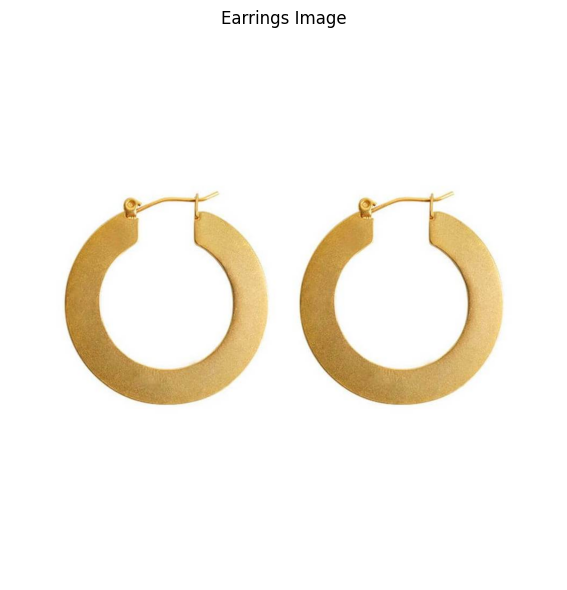

In [9]:
# reading the image
img = cv2.imread('../images/earrings.jpg')

# cv2 reads as BGR not RGB so need to convert before showing with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Image size (H x W): {img.shape[0]} x {img.shape[1]} pixels")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title('Earrings Image')
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 2 — Convert to grayscale and threshold
To measure the earring in pixels we need to isolate it from the background.
The earrings are gold coloured on a white background so thresholding works well.
We invert the binary image so the earring pixels are white (255) and 
background is black (0).

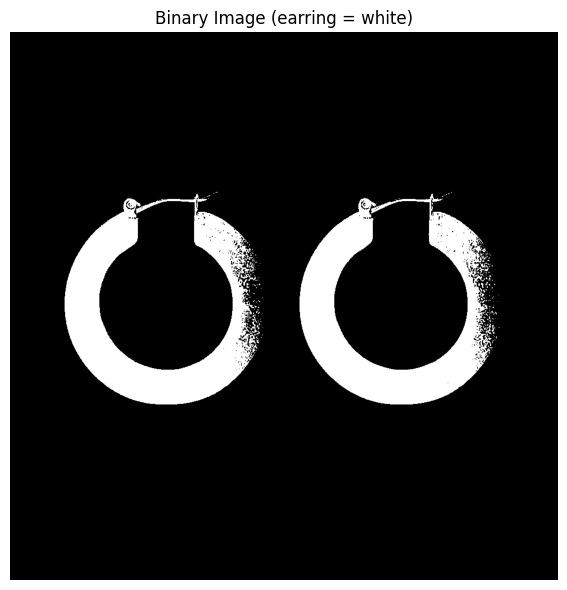

In [10]:
# convert to grayscale first
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# background is white so anything darker than 200 is the earring
# THRESH_BINARY_INV flips it so earring = white, background = black
_, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(6, 6))
plt.imshow(binary, cmap='gray')
plt.title('Binary Image (earring = white)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3 — Find contours and measure the earring
We use contours to find the boundary of each earring.
From the largest contour we can get a bounding circle which
gives us the outer diameter in pixels.
We also measure the ring thickness by looking at the difference
between the outer and inner radius.

Number of contours found: 556
  Contour 1: area = 51262 px²
  Contour 2: area = 51180 px²
  Contour 3: area = 89 px²
  Contour 4: area = 88 px²
  Contour 5: area = 86 px²

Earring 1:
  Centre   : (292.5, 495.4)
  Radius   : 201.5 px
  Diameter : 403.0 px

Earring 2:
  Centre   : (731.1, 495.2)
  Radius   : 201.6 px
  Diameter : 403.3 px


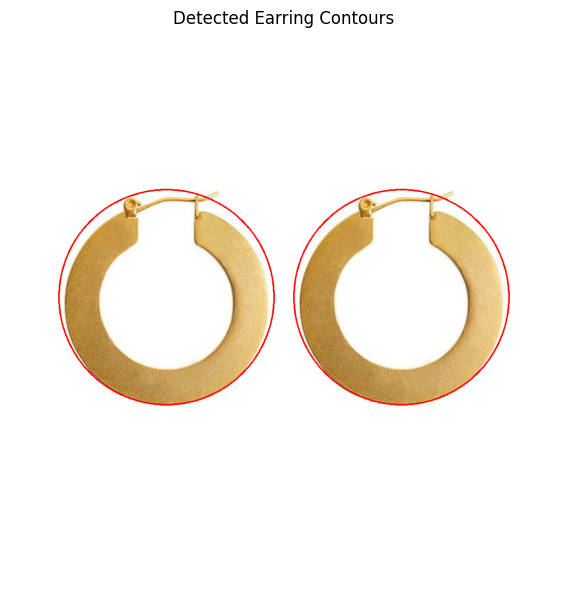


Average outer diameter: 403.2 px


In [11]:
# find contours in the binary image
contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# sort by area so biggest contours come first
contours = sorted(contours, key=cv2.contourArea, reverse=True)

print(f"Number of contours found: {len(contours)}")
for j, cnt in enumerate(contours[:5]):
    print(f"  Contour {j+1}: area = {cv2.contourArea(cnt):.0f} px²")

# two biggest contours should be the two earrings
img_contours = img_rgb.copy()
diameters_px = []

for j in range(2):
    cnt = contours[j]
    # fit a circle around each earring to get the diameter
    (cx, cy), radius = cv2.minEnclosingCircle(cnt)
    diameter_px = 2 * radius
    diameters_px.append(diameter_px)
    
    cv2.circle(img_contours, (int(cx), int(cy)), int(radius), (255, 0, 0), 2)
    print(f"\nEarring {j+1}:")
    print(f"  Centre   : ({cx:.1f}, {cy:.1f})")
    print(f"  Radius   : {radius:.1f} px")
    print(f"  Diameter : {diameter_px:.1f} px")

plt.figure(figsize=(6, 6))
plt.imshow(img_contours)
plt.title('Detected Earring Contours')
plt.axis('off')
plt.tight_layout()
plt.show()

# average diameter of both earrings
avg_diameter_px = np.mean(diameters_px)
print(f"\nAverage outer diameter: {avg_diameter_px:.1f} px")

## Step 4 — Measure ring thickness in pixels
The earring is a hoop so it has an outer edge and an inner hole.
Instead of relying on contours for the inner hole (which picked up noise),
we measure the inner radius directly from the binary image.

For each earring centre we scan horizontally across the image and find
where the earring pixels start and end — this gives us the inner hole size.

Earring 1:
  Outer radius : 201.5 px
  Inner radius : 125.0 px
  Thickness    : 76.5 px
Earring 2:
  Outer radius : 201.6 px
  Inner radius : 125.0 px
  Thickness    : 76.6 px


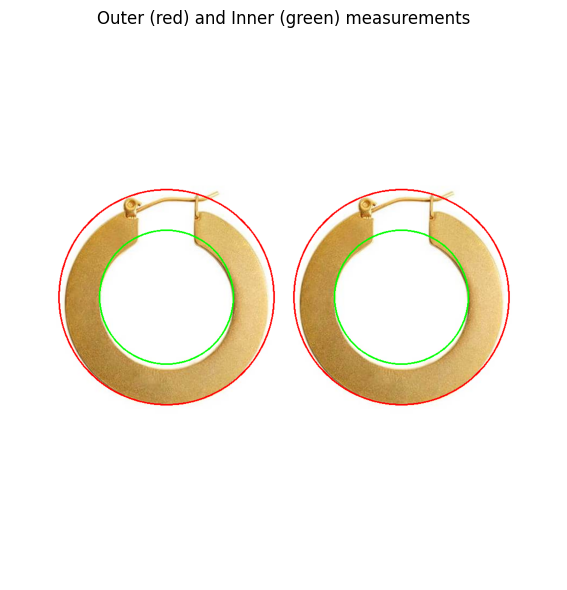


Average outer radius : 201.6 px
Average inner radius : 125.0 px
Ring thickness       : 76.6 px


In [12]:
# the contour approach didnt work well for the inner hole - got noise contours
# instead we measure the inner radius directly from the binary image
# scan a horizontal line through each earring centre and find the hole

inner_radii_px = []
img_measure = img_rgb.copy()

for j in range(2):
    cnt = contours[j]
    (cx, cy), outer_radius = cv2.minEnclosingCircle(cnt)
    cx, cy = int(cx), int(cy)
    
    # take a horizontal row through the earring centre
    row = binary[cy, :]
    
    # find pixel positions where the earring is white (255) near the centre
    # scan from centre outward to find where the hole ends (background inside ring)
    # go left from centre - find first white pixel = inner edge
    inner_left = cx
    for px in range(cx, cx - int(outer_radius), -1):
        if row[px] == 255:
            inner_left = px
            break
    
    # go right from centre - find first white pixel = inner edge
    inner_right = cx
    for px in range(cx, cx + int(outer_radius)):
        if row[px] == 255:
            inner_right = px
            break
    
    # inner radius = half the gap between the two inner edges
    inner_radius = (inner_right - inner_left) / 2
    inner_radii_px.append(inner_radius)
    
    # draw inner circle for visualisation
    cv2.circle(img_measure, (cx, cy), int(inner_radius), (0, 255, 0), 2)
    cv2.circle(img_measure, (cx, cy), int(outer_radius), (255, 0, 0), 2)
    
    print(f"Earring {j+1}:")
    print(f"  Outer radius : {outer_radius:.1f} px")
    print(f"  Inner radius : {inner_radius:.1f} px")
    print(f"  Thickness    : {outer_radius - inner_radius:.1f} px")

plt.figure(figsize=(6, 6))
plt.imshow(img_measure)
plt.title('Outer (red) and Inner (green) measurements')
plt.axis('off')
plt.tight_layout()
plt.show()

avg_inner_radius_px = np.mean(inner_radii_px)
avg_outer_radius_px = avg_diameter_px / 2
thickness_px = avg_outer_radius_px - avg_inner_radius_px

print(f"\nAverage outer radius : {avg_outer_radius_px:.1f} px")
print(f"Average inner radius : {avg_inner_radius_px:.1f} px")
print(f"Ring thickness       : {thickness_px:.1f} px")

## Step 5 — Apply the pinhole camera model formula
Now we convert pixel measurements to real-world mm using:

    real_size = (pixel_count × pixel_size × Z) / f

Where:
- pixel_size = 0.0022 mm  (given: 2.2 µm)
- Z = 720 mm              (given: lens to imaging plane distance)
- f = 8 mm                (given: focal length)

In [13]:
# camera parameters given in the assignment
f          = 8       # focal length in mm
pixel_size = 0.0022  # 2.2 micrometres converted to mm
Z          = 720     # distance from lens to imaging plane in mm

# pinhole camera formula from lecture
# real_size = (pixel_count * pixel_size * Z) / f
outer_diameter_mm = (avg_diameter_px * pixel_size * Z) / f
print(f"Outer diameter of earring : {outer_diameter_mm:.2f} mm")

if len(inner_radii_px) == 2:
    thickness_mm      = (thickness_px * pixel_size * Z) / f
    inner_diameter_mm = (avg_inner_radius_px * 2 * pixel_size * Z) / f
    print(f"Inner diameter of earring : {inner_diameter_mm:.2f} mm")
    print(f"Ring thickness            : {thickness_mm:.2f} mm")

Outer diameter of earring : 79.82 mm
Inner diameter of earring : 49.50 mm
Ring thickness            : 15.16 mm


## Results Summary

| Measurement | Pixels | Real Size (mm) |
|-------------|--------|----------------|
| Outer diameter | 403.2 px | 79.82 mm |
| Inner diameter | 250.0 px | 49.50 mm |
| Ring thickness | 76.6 px | 15.16 mm |

## Observation
The pinhole camera model uses similar triangles to relate image 
measurements to real world sizes. The formula is:

    real_size = (pixel_count × pixel_size × Z) / f

The outer diameter came out to around 79.82 mm which seems reasonable 
for a large hoop earring.

The inner hole measurement was tricky — the contour approach picked up 
noise instead of the actual hole, so we scanned horizontally through 
the earring centre to find where the ring material starts on each side.

One thing to note is that the accuracy of this method depends on how 
precisely we can measure pixel distances in the image. Any distortion 
in the image or slight angle of the camera would affect the result.